# Features Engineer - Lựa chọn đặc trưng

Sau khi đã xây dựng các mô hình cơ sở là Vanilla LightGBM Model, chúng tôi đã quyết định sử dụng những mô hình dự đoán dựa trên nhiều features thay vì chỉ dựa vào các chu kỳ, mùa vụ. Vì vậy trong notebooks này, chúng tôi sẽ tập hợp những features có khả năng cao góp phần vào `revenue`, xây dựng một tập dữ liệu huấn luyện mới và tối ưu để cải thiện các mô hình huấn luyện.
 
- Khám phá toàn bộ đặc trưng từ datasets
- Kiểm tra mối tương quan với tập `sales.csv`
- Lựa chọn những đặc trưng tốt nhất cho mô hình
- Xử lý là lưu dữ liệu cho việc train model

**Mục tiêu**: Chúng tôi muốn từng bước cải thiện model bắt đầu từ việc khám phá các đặc trưng trước

**Mục lục**
1. [Cài đặt và thiết lập](#1)
2. [Khám phá các đặc trưng](#2)
3. [Trực quan hóa](#3)
4. [Các kỹ thuật lựa chọn đặc trưng](#4)

<a id = "1"></a>

## 1. Cài đặt và thiết lập
Nhập thư viện cần thiết và kết nối tới database `datathon.duckdb`

In [2]:
# các thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.connection import get_connection

In [3]:
# Kết nối database
try:
    con = get_connection()
    print("[OKE] Kết nối đến database thành công.")
except:
    print("Không thể kết nối đến database.")

[OKE] Kết nối đến database thành công.


In [4]:
df = con.execute("SELECT * FROM sales").df()
df.head()

,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


<a id="2"></a>

## 2. Đặc trưng về tính chu kỳ, mùa vụ
Như đã phân tích trước đó, `revenue` đang có tính chu kỳ rõ rệt theo ngày, tuần, tháng và năm. Vì vậy trong phần này, chúng tôi sẽ tạo ra thêm các features mới dựa trên dữ liệu từ quá khứ để mô hình có thể nhận biết rõ doanh thu biến động qua các chu kỳ như thế nào.

### 2.1 Tạo các đặc trưng liên quan

In [5]:
# Lấy dữ liệu doanh thu
df_revenue = df.drop('cogs', axis=1)
df_revenue.head()

,date,revenue
0,2012-07-04,5123547.94
1,2012-07-05,2751773.45
2,2012-07-06,3054029.42
3,2012-07-07,2667930.94
4,2012-07-08,2360851.90


In [80]:
# Tạo các features dựa trên cột revenue (Time-Series Features)
df_features = df_revenue.copy()
df_features['date'] = pd.to_datetime(df_features['date'])
df_features = df_features.sort_values('date').reset_index(drop=True)

# 1. Lag Features (Giá trị trễ - Doanh thu của các ngày trước đó)
df_features['lag_1'] = df_features['revenue'].shift(1)   # Ngày hôm qua
df_features['lag_7'] = df_features['revenue'].shift(7)   # Cùng ngày tuần trước
df_features['lag_14'] = df_features['revenue'].shift(14) # Cùng ngày 2 tuần trước
df_features['lag_30'] = df_features['revenue'].shift(30) # Cùng ngày tháng trước

# 2. Rolling Window Features (Đặc trưng cửa sổ trượt)
# LƯU Ý QUAN TRỌNG: Phải tính rolling trên giá trị đã bị trễ (shift(1)) để tránh Look-ahead bias (rò rỉ dữ liệu tương lai vào tập huấn luyện)
shifted_rev = df_features['revenue'].shift(1)

# Trung bình trượt (Rolling Mean) - Thể hiện xu hướng (Trend)
df_features['rolling_mean_3'] = shifted_rev.rolling(window=3).mean()
df_features['rolling_mean_7'] = shifted_rev.rolling(window=7).mean()
df_features['rolling_mean_14'] = shifted_rev.rolling(window=14).mean()
df_features['rolling_mean_30'] = shifted_rev.rolling(window=30).mean()

# Độ lệch chuẩn trượt (Rolling Std) - Thể hiện mức độ biến động (Volatility)
df_features['rolling_std_3'] = shifted_rev.rolling(window=3).std()
df_features['rolling_std_7'] = shifted_rev.rolling(window=7).std()
df_features['rolling_std_30'] = shifted_rev.rolling(window=30).std()

# Min/Max trượt - Thể hiện biên độ cực đại/cực tiểu trong ngắn hạn
df_features['rolling_min_7'] = shifted_rev.rolling(window=7).min()
df_features['rolling_max_7'] = shifted_rev.rolling(window=7).max()
df_features['rolling_max_30'] = shifted_rev.rolling(window=30).max()


# Biến động tuyệt đối giữa ngày hôm qua và ngày trước đó
df_features['diff_1'] = shifted_rev.diff(1)
# Biến động tuần (so sánh cùng ngày giữa 2 tuần)
df_features['diff_7'] = shifted_rev.diff(7)

# 4. Đặc trưng Rủi ro / Tỉ lệ (Ratios)
# So sánh doanh thu hôm qua so với trung bình 7 ngày trước đó (đánh giá đà tăng trưởng trực tiếp)
df_features['ratio_lag1_to_avg7'] = df_features['lag_1'] / (df_features['rolling_mean_7'] + 1e-5) # Tránh chia cho 0

# Tiếp tục sử dụng biến shifted_rev đã có từ code của bạn
df_features['pct_change_1'] = shifted_rev.pct_change(1)

# # 2. Đặc trưng tích lũy (Expanding)
df_features['expanding_max'] = shifted_rev.expanding().max()

# 3. Chỉ số biến động chuẩn hóa (Z-Score) 
# Giúp mô hình nhận diện hôm qua là một ngày "bình thường" hay "đột biến"
df_features['z_score_7'] = (df_features['lag_1'] - df_features['rolling_mean_7']) / (df_features['rolling_std_7'] + 1e-5)
df_features['z_score_30'] = (df_features['lag_1'] - df_features['rolling_mean_30']) / (df_features['rolling_std_30'] + 1e-5)

print("Đã tạo xong các Time-series Features từ cột Revenue!")
print("Số lượng features hiện tại:", df_features.shape[1])
df_features.tail(10)

Đã tạo xong các Time-series Features từ cột Revenue!
Số lượng features hiện tại: 23


,date,revenue,lag_1,lag_7,lag_14,lag_30,rolling_mean_3,rolling_mean_7,rolling_mean_14,rolling_mean_30,...,rolling_min_7,rolling_max_7,rolling_max_30,diff_1,diff_7,ratio_lag1_to_avg7,pct_change_1,expanding_max,z_score_7,z_score_30
3823,2022-12-22,1791622.46,1795395.02,1494318.64,818209.67,853188.02,2.024324e+06,1.793293e+06,1.643715e+06,1.565001e+06,...,1302193.74,2250767.39,3138619.13,-231415.06,133151.43,1.001172,-0.114177,20905271.35,0.005559,0.397569
3824,2022-12-23,1501209.11,1791622.46,1482192.97,1323267.85,1060969.69,1.871276e+06,1.835765e+06,1.713245e+06,1.596282e+06,...,1302193.74,2250767.39,3138619.13,-3772.56,297303.82,0.975954,-0.002101,20905271.35,-0.124384,0.345794
3825,2022-12-24,1390870.89,1501209.11,1302193.74,1598936.84,1729664.20,1.696076e+06,1.838482e+06,1.725955e+06,1.610957e+06,...,1302193.74,2250767.39,3138619.13,-290413.35,19016.14,0.816548,-0.162095,20905271.35,-0.958726,-0.197329
3826,2022-12-25,1136772.53,1390870.89,2201374.59,1420910.74,1527923.90,1.561234e+06,1.851150e+06,1.711093e+06,1.599664e+06,...,1390870.89,2250767.39,3138619.13,-110338.22,88677.15,0.751355,-0.073500,20905271.35,-1.393958,-0.374777
3827,2022-12-26,2110830.12,1136772.53,2250767.39,1983085.06,2035639.78,1.342951e+06,1.699064e+06,1.690798e+06,1.586626e+06,...,1136772.53,2250767.39,3138619.13,-254098.36,-1064602.06,0.669058,-0.182690,20905271.35,-1.468284,-0.798473
3828,2022-12-27,2100553.66,2110830.12,2026810.08,1652309.19,3138619.13,1.546158e+06,1.679073e+06,1.699922e+06,1.589132e+06,...,1136772.53,2110830.12,3138619.13,974057.59,-139937.27,1.257140,0.856862,20905271.35,1.227495,0.922346
3829,2022-12-28,3448729.20,2100553.66,1795395.02,1662243.59,2104917.42,1.782719e+06,1.689608e+06,1.731940e+06,1.554530e+06,...,1136772.53,2110830.12,2558728.79,-10276.46,73743.58,1.243220,-0.004868,20905271.35,1.126643,1.103321
3830,2022-12-29,3083944.33,3448729.20,1791622.46,1494318.64,2558728.79,2.553371e+06,1.925798e+06,1.859546e+06,1.599323e+06,...,1136772.53,3448729.20,3448729.20,1348175.54,1653334.18,1.790805,0.641819,20905271.35,1.996530,3.099090
3831,2022-12-30,2884668.76,3083944.33,1501209.11,1482192.97,1317689.52,2.877742e+06,2.110416e+06,1.973090e+06,1.616831e+06,...,1136772.53,3448729.20,3448729.20,-364784.87,1292321.87,1.461297,-0.105774,20905271.35,1.114785,2.319519
3832,2022-12-31,2383037.48,2884668.76,1390870.89,1302193.74,1668445.90,3.139114e+06,2.308053e+06,2.073267e+06,1.669063e+06,...,1136772.53,3448729.20,3448729.20,-199275.57,1383459.65,1.249828,-0.064617,20905271.35,0.663558,1.812952


### 2.2 Đánh giá dựa trên mô hình baseline

In [81]:
from src.baseline_models import evaluate_vanilla_lightgbm

# Thêm đặc trưng thời gian tĩnh (nếu chưa có)
if 'day_of_week' not in df_features.columns:
    df_features['day_of_week'] = df_features['date'].dt.dayofweek
if 'month' not in df_features.columns:
    df_features['month'] = df_features['date'].dt.month

# Lấy toàn bộ các trường làm features ngoại trừ các cột mục tiêu / định danh dư thừa
exclude_cols = ['date', 'revenue']
feature_cols = [col for col in df_features.columns if col not in exclude_cols]

print(f"Đang huấn luyện với {len(feature_cols)} features...")

# Chạy hàm đánh giá
val_lgbm_features, metrics_features = evaluate_vanilla_lightgbm(
    df=df_features, 
    features_col=feature_cols,
    target_col='revenue'
)

print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH VỚI TIME-SERIES FEATURES MỚI ---")
print(f"MAE  (Sai số tuyệt đối)   : {metrics_features['MAE']:,.2f}")
print(f"RMSE (Sai số bình phương) : {metrics_features['RMSE']:,.2f}")
print(f"MAPE (Sai số phần trăm)   : {metrics_features['MAPE']:.2f}%")
print(f"R-squared (Độ phù hợp)    : {metrics_features['R-squared']:.4f}")

Đang huấn luyện với 23 features...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5117
[LightGBM] [Info] Number of data points in the train set: 3438, number of used features: 23
[LightGBM] [Info] Start training from score 4395427.630081

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH VỚI TIME-SERIES FEATURES MỚI ---
MAE  (Sai số tuyệt đối)   : 601,247.09
RMSE (Sai số bình phương) : 869,868.89
MAPE (Sai số phần trăm)   : 22.65%
R-squared (Độ phù hợp)    : 0.7299


### 2.3 Trực quan hóa kết quả dự đoán và Đặc trưng quan trọng

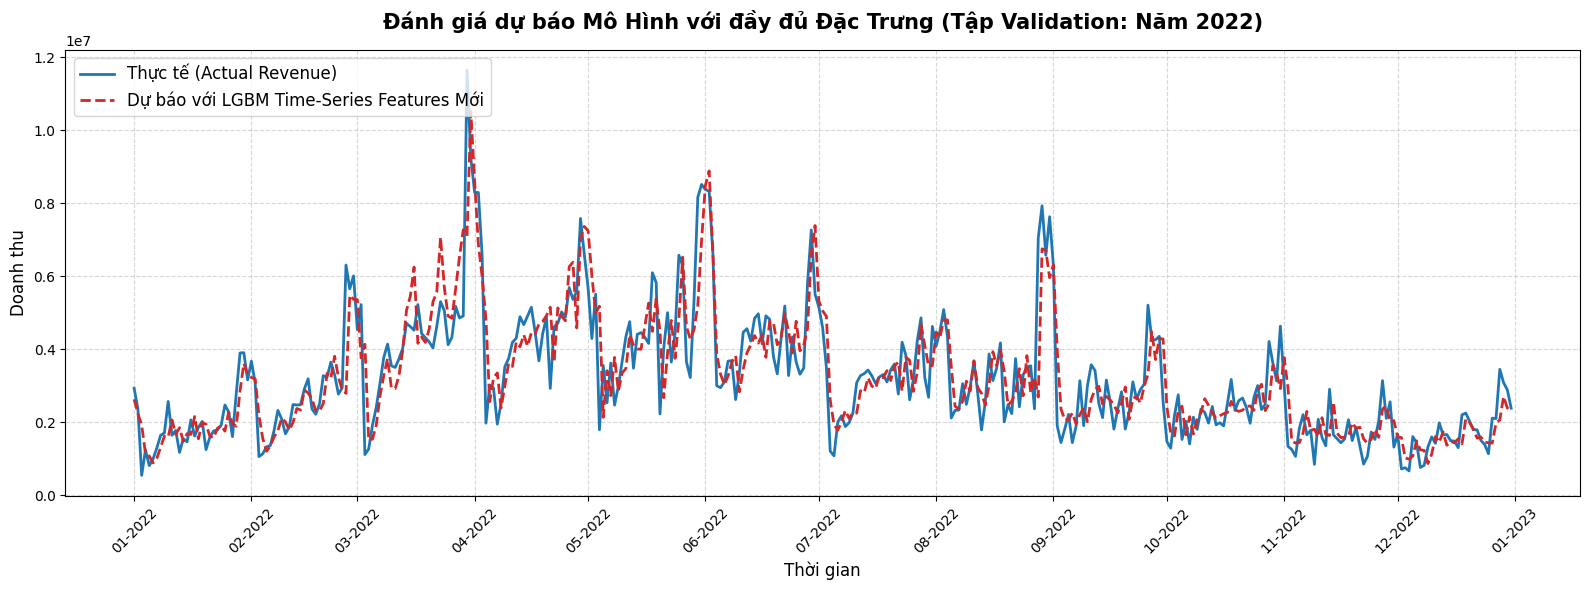

In [44]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import lightgbm as lgb
import pandas as pd

# --- 1. VẼ BIỂU ĐỒ SO SÁNH THỰC TẾ & DỰ ĐOÁN TẬP TEST (2022) ---
plt.figure(figsize=(16, 6))

# Vẽ 2 đường Thực tế (Màu xanh) và Dự báo LGBM Features (Màu đỏ)
plt.plot(val_lgbm_features['date'], val_lgbm_features['revenue'], label='Thực tế (Actual Revenue)', color='#1f77b4', linewidth=2)
plt.plot(val_lgbm_features['date'], val_lgbm_features['lgbm_revenue'], label='Dự báo với LGBM Time-Series Features Mới', color='#d62728', linestyle='--', linewidth=2)

plt.title('Đánh giá dự báo Mô Hình với đầy đủ Đặc Trưng (Tập Validation: Năm 2022)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.xticks(rotation=45) 

plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5632
[LightGBM] [Info] Number of data points in the train set: 3468, number of used features: 25
[LightGBM] [Info] Start training from score 4400440.527528


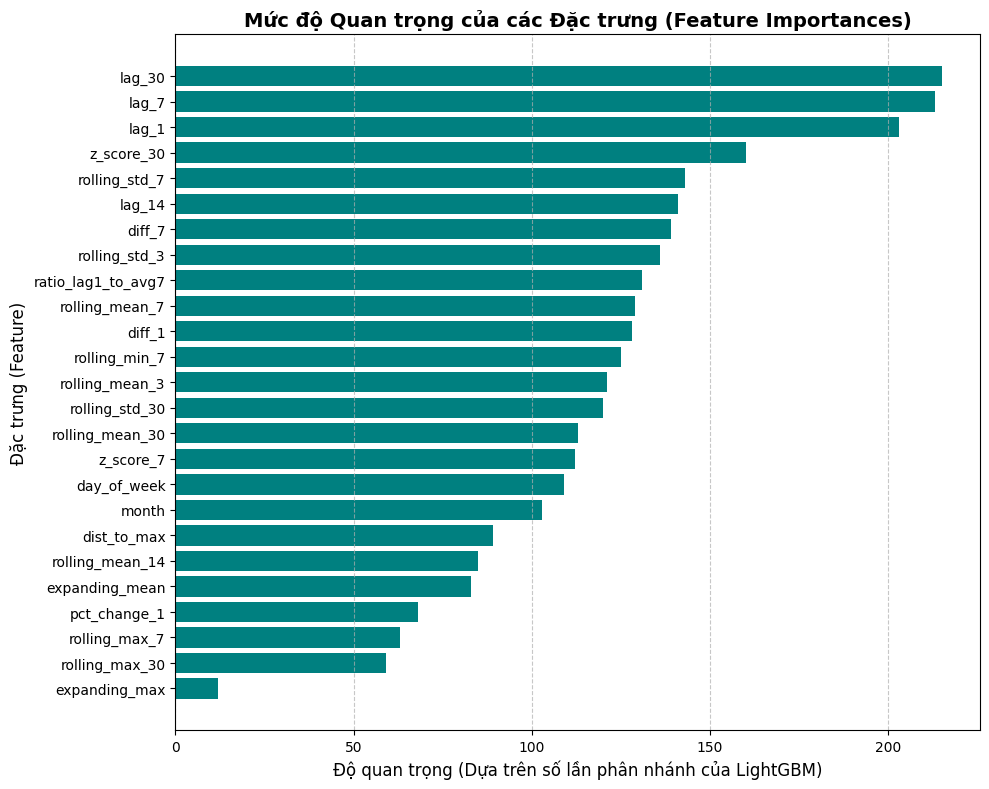

In [45]:
# --- 2. VẼ BIỂU ĐỒ ĐẶC TRƯNG QUAN TRỌNG (FEATURE IMPORTANCE) ---
# Chạy train thử một mô hình LightGBM nguyên bản (tương tự như hàm đánh giá) để lấy trọng số Feature Importance
train = df_features[df_features['date'] <= '2021-12-31'].copy()
X_train = train[feature_cols]
y_train = train['revenue']

# Khởi tạo mô hình và fit data
model_fi = lgb.LGBMRegressor(random_state=42)
model_fi.fit(X_train, y_train)

# Tạo dataframe chứa mức độ quan trọng
fi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model_fi.feature_importances_
}).sort_values(by='Importance', ascending=True) # Sort tăng dần để đoạn dưới plot barh từ thấp lên cao

# Trực quan hóa Feature Importance (Bằng matplotlib thay cho seaborn)
plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='teal')

plt.title('Mức độ Quan trọng của các Đặc trưng (Feature Importances)', fontsize=14, fontweight='bold')
plt.xlabel('Độ quan trọng (Dựa trên số lần phân nhánh của LightGBM)', fontsize=12)
plt.ylabel('Đặc trưng (Feature)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Kết luận:**
Dựa trên kết quả sau khi sử dụng thêm các features mới để cải thiện mô hình baseline `Vanilla LightGBM Model` đã giúp chô hình dự đoán giảm đi 3% sai số. Xong sau đó chúng ta cũng có thể thấy một vài features quan trọng như:
- `lag_1`
- `lag_30`
- `lag_7`

<a id = "3"></a>

## 3. Các đặc trưng khác
Dựa trên notebooks [01_ANALYSIS_.ipynb](01_ANALYSIS_.ipynb) đã phân tích trước đó, chúng tôi đã kiểm tra một vài các đặc trưng liên quan  
Phần này sẽ tập trung tìm hiểu các đặc trưng khác cho tập dữ liệu `sales.csv`  
Các đặc trưng đáng chú ý tới: `promotions.csv`, `reviews.csv`, `web_traffic.csv`

<a id = "4"></a>

## 4. Trực quan hóa
Sau khi đã kiểm tra lại toàn bộ đặc trưng của tập dataset, chúng tôi bắt đầu đi vào phân tích kỹ mối tương quan với tập dữ liệu của chúng tôi qua biểu đồ

<a id = "5"></a>

## 5. Các kỹ thuật lựa chọn đặc trưng
Từ các đặc trưng quan trọng ở phần [4. Trực quan hóa](#4), việc áp dụng các kỹ thuật lựa chọn đặc trưng cũng vô cùng quan trọng để lọc ra tiếp các features tốt nhất

---
**Kết luận:**

---
**Notebooks tiếp theo:** []() - 